# BRFSS 2015 Diabetes — Model Training and Selection

This notebook picks up where `01_data_exploration_and_preprocessing.ipynb` left off. That notebook
cleaned the data, split it, and saved the results; this one trains four candidate
models on the training set and compares them.

**Inputs** (produced by the previous notebook — both must be in this folder):
- `brfss_train_test.npz` — the processed train/test arrays
- `brfss_preprocessor.joblib` — the fitted scaler

**The test set is not touched anywhere in this notebook.** All model comparison is
done with cross-validation *inside* the training set. The 45,957 held-out records are
opened only once, in the final phase, after a single model has been chosen.

Run cells with **Shift + Enter**, or use **Run All**. The whole notebook takes well
under a minute.

## 1. Setup

Run the install cell once if LightGBM is missing, then comment it out.

In [1]:
# %pip install lightgbm

In [2]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier

sns.set_theme(style="whitegrid")
%matplotlib inline
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("Libraries loaded.")

Libraries loaded.


## 2. Load the prepared data

Nothing is re-cleaned here. The arrays are loaded exactly as the preprocessing
notebook saved them, which is the whole point of having saved them.

In [3]:
data = np.load("brfss_train_test.npz", allow_pickle=True)

X_train = data["X_train"]
X_test = data["X_test"]      # loaded for completeness only - NOT used in this notebook
y_train = data["y_train"]
y_test = data["y_test"]      # likewise
feature_names = list(data["feature_names"])

print(f"Training set : {X_train.shape[0]:,} rows x {X_train.shape[1]} features")
print(f"Testing set  : {X_test.shape[0]:,} rows  (held back, not used below)")
print(f"\nFeatures: {feature_names}")

Training set : 183,824 rows x 21 features
Testing set  : 45,957 rows  (held back, not used below)

Features: ['BMI', 'MentHlth', 'PhysHlth', 'GenHlth', 'Age', 'Education', 'Income', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']


In [4]:
# Class balance in the training set, and the weight needed to correct for it
n_pos = int(y_train.sum())
n_neg = int((y_train == 0).sum())
scale_pos_weight = n_neg / n_pos

print(f"Non-diabetic (0): {n_neg:,}")
print(f"Diabetic     (1): {n_pos:,}")
print(f"Positive rate   : {y_train.mean() * 100:.2f}%")
print(f"\nscale_pos_weight = {n_neg:,} / {n_pos:,} = {scale_pos_weight:.4f}")
print("\nEvery model below is told to weight the diabetic class by roughly this much,")
print("so that the minority class is not ignored during training.")

Non-diabetic (0): 152,043
Diabetic     (1): 31,781
Positive rate   : 17.29%

scale_pos_weight = 152,043 / 31,781 = 4.7841

Every model below is told to weight the diabetic class by roughly this much,
so that the minority class is not ignored during training.


## 3. The four candidate models

Three simple models, each from a **different algorithm family**, plus one advanced
ensemble. Using three different families rather than three variations on one theme
means the comparison actually tells us something about the shape of the data.

| # | Model | Family | Why it is here |
|---|-------|--------|----------------|
| 1 | Logistic Regression | Linear | The interpretable baseline. Each coefficient converts to an odds ratio, so the model can state *how much* each risk factor raises the odds of diabetes — which is exactly what a clinician would ask. |
| 2 | Decision Tree | Rule-based | Captures non-linear effects and interactions that a linear model cannot, and produces a flowchart of yes/no questions that needs no statistical background to read. |
| 3 | Gaussian Naive Bayes | Probabilistic | The fastest possible baseline. Its job is to set a floor: if a complex model cannot clearly beat it, that complexity is not earning its place. |
| 4 | **LightGBM** | Gradient-boosted ensemble | The advanced model. Gradient boosting on decision trees is the strongest general method for structured tabular data of this kind, and it handles class imbalance directly through `scale_pos_weight`. |

### Two models that were deliberately left out

- **K-Nearest Neighbours** — has no training phase, so all the work happens at
  prediction time: classifying the test set would mean measuring the distance from
  each of 45,957 records to all 183,824 training records. It is also weakened by
  having 21 dimensions, where distances between points become less meaningful.
- **Random Forest** — a good model, but it is a tree ensemble, and LightGBM is
  already representing that family in a stronger form. Including both would test the
  same idea twice instead of adding a genuinely different one.

In [5]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",   # corrects the 17% / 83% imbalance
        max_iter=1000,             # the default 100 is not always enough to converge
        random_state=42,
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,               # unconstrained, a tree on 183k rows memorises the data
        min_samples_leaf=50,       # no rule may be based on fewer than 50 people
        class_weight="balanced",
        random_state=42,
    ),

    "Gaussian Naive Bayes": GaussianNB(
        priors=[0.5, 0.5],         # NB has no class_weight; equal priors is the equivalent
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=400,          # number of boosting rounds
        learning_rate=0.05,        # smaller steps, more rounds - the usual trade
        num_leaves=31,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=4,
        verbose=-1,                # silence LightGBM's per-round chatter
    ),
}

for name, m in models.items():
    print(f"{name:22s} -> {type(m).__name__}")

Logistic Regression    -> LogisticRegression
Decision Tree          -> DecisionTreeClassifier
Gaussian Naive Bayes   -> GaussianNB
LightGBM               -> LGBMClassifier


## 4. Cross-validated comparison

The training set is split into 5 folds. Each model is trained on 4 folds and scored on
the 5th, five times over, and the scores are averaged. This gives every model a fair
estimate of how it performs on data it has not seen — **without ever touching the real
test set**.

The folds are *stratified*, so each one keeps the same 17.29% positive rate as the
whole training set.

### The metrics, and why accuracy is not among them

| Metric | What it answers |
|---|---|
| **Recall** | Of everyone who has diabetes, what fraction did we catch? **The one that matters most here** — a missed case is far worse than a false alarm, which only costs an unnecessary blood test. |
| **Precision** | Of everyone we flagged, what fraction actually has diabetes? Determines how much unnecessary testing the tool generates. |
| **F1** | The balance between the two above. |
| **ROC-AUC** | How well the model *ranks* people by risk, independent of where the cut-off is set. |
| **PR-AUC** | Like ROC-AUC, but focused on the minority class — the more honest summary when the data is imbalanced. |

Accuracy is left out on purpose: predicting "not diabetic" for everyone scores about
83% on this data while being useless.

In [6]:
scoring = ["recall", "precision", "f1", "roc_auc", "average_precision"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for name, model in models.items():
    t0 = time.time()
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=5)
    elapsed = time.time() - t0

    rows.append({
        "Model": name,
        "Recall": res["test_recall"].mean(),
        "Precision": res["test_precision"].mean(),
        "F1": res["test_f1"].mean(),
        "ROC-AUC": res["test_roc_auc"].mean(),
        "PR-AUC": res["test_average_precision"].mean(),
        "Recall SD": res["test_recall"].std(),
        "Fit time (s)": res["fit_time"].mean(),
    })
    print(f"{name:22s} finished in {elapsed:5.1f}s")

results = pd.DataFrame(rows).set_index("Model")
print("\nAll models cross-validated.")

Logistic Regression    finished in   2.7s


Decision Tree          finished in   0.5s


Gaussian Naive Bayes   finished in   0.4s


LightGBM               finished in   2.0s

All models cross-validated.


In [7]:
# Sorted by ROC-AUC, the fairest single summary for comparing models
results.sort_values("ROC-AUC", ascending=False).round(4)

,Recall,Precision,F1,ROC-AUC,PR-AUC,Recall SD,Fit time (s)
Model,,,,,,,
LightGBM,0.7715,0.3458,0.4776,0.8088,0.4600,0.0045,1.4089
Logistic Regression,0.7493,0.3490,0.4762,0.8021,0.4396,0.0052,0.4608
Decision Tree,0.7347,0.3407,0.4653,0.7903,0.4175,0.0177,0.3133
Gaussian Naive Bayes,0.7089,0.3270,0.4475,0.7622,0.3736,0.0061,0.1002


## 5. Comparing the results visually

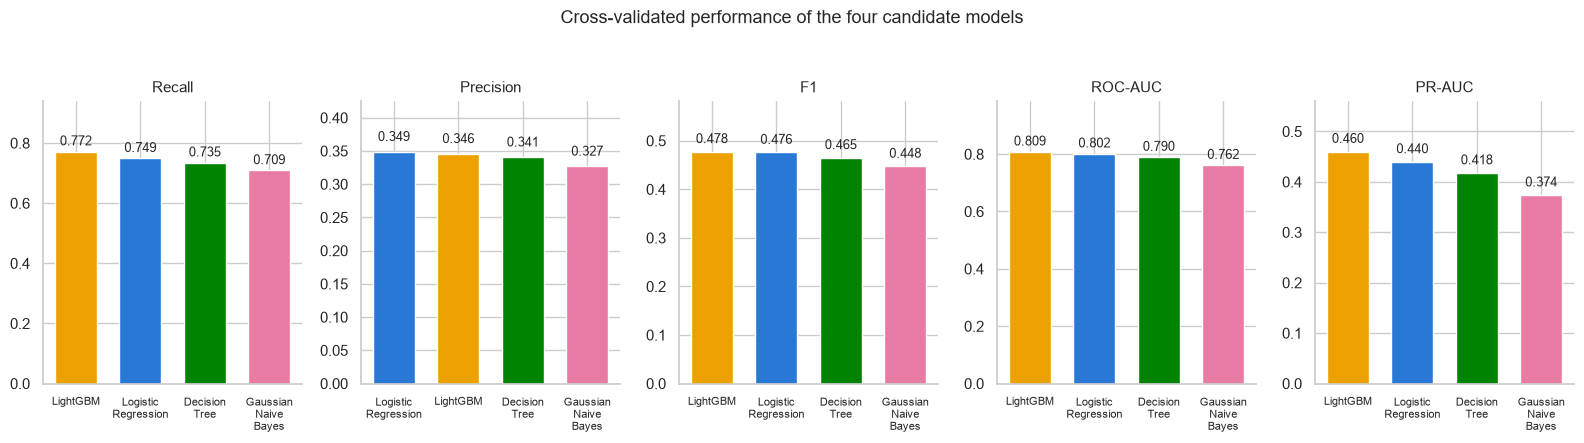

Saved to model_comparison.png


In [8]:
PALETTE = ["#2a78d6", "#008300", "#e87ba4", "#eda100"]   # one fixed colour per model
colours = {name: PALETTE[i] for i, name in enumerate(models)}

metrics = ["Recall", "Precision", "F1", "ROC-AUC", "PR-AUC"]
fig, axes = plt.subplots(1, len(metrics), figsize=(16, 4.5), sharey=False)

for ax, metric in zip(axes, metrics):
    vals = results[metric].sort_values(ascending=False)
    bars = ax.bar(range(len(vals)), vals.values,
                  color=[colours[n] for n in vals.index], width=0.65)
    for b, v in zip(bars, vals.values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_title(metric, fontsize=11)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([n.replace(" ", "\n") for n in vals.index], fontsize=8)
    ax.set_ylim(0, max(vals.values) * 1.22)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Cross-validated performance of the four candidate models", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved to model_comparison.png")

In [9]:
best = results["ROC-AUC"].idxmax()
simple_best = results.drop(index="LightGBM")["ROC-AUC"].idxmax()
gap = results.loc[best, "ROC-AUC"] - results.loc[simple_best, "ROC-AUC"]

print(f"Best overall           : {best}  (ROC-AUC {results.loc[best, 'ROC-AUC']:.4f})")
print(f"Best simple model      : {simple_best}  (ROC-AUC {results.loc[simple_best, 'ROC-AUC']:.4f})")
print(f"Gap between the two    : {gap:.4f}")
print()
print("A small gap is a genuinely useful finding, not a disappointment: it means the")
print("simple, explainable model is doing almost as well as the advanced one, which is")
print("a strong argument in a medical setting where decisions must be justified.")

Best overall           : LightGBM  (ROC-AUC 0.8088)
Best simple model      : Logistic Regression  (ROC-AUC 0.8021)
Gap between the two    : 0.0067

A small gap is a genuinely useful finding, not a disappointment: it means the
simple, explainable model is doing almost as well as the advanced one, which is
a strong argument in a medical setting where decisions must be justified.


## 6. Fit the final models and save them

Cross-validation was used only to *compare* the models. Each one is now retrained on
the full training set and saved, so the next phase can load them directly.

In [10]:
fitted = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    fitted[name] = model
    fname = name.lower().replace(" ", "_") + ".joblib"
    joblib.dump(model, fname)
    print(f"{name:22s} trained in {time.time() - t0:5.1f}s  ->  {fname}")

results.to_csv("model_comparison_results.csv")
print("\nScores saved to model_comparison_results.csv")

Logistic Regression    trained in   1.1s  ->  logistic_regression.joblib


Decision Tree          trained in   0.8s  ->  decision_tree.joblib
Gaussian Naive Bayes   trained in   0.1s  ->  gaussian_naive_bayes.joblib


LightGBM               trained in   3.0s  ->  lightgbm.joblib

Scores saved to model_comparison_results.csv


## 7. What the models learned

A score alone does not explain *why* a model flags someone. These next cells open up
the two most interpretable models, and give the report something to say beyond a
table of numbers.

### 7.1 Logistic Regression — odds ratios

Each coefficient is converted to an **odds ratio**. A value of 1.5 means that feature
multiplies the odds of diabetes by 1.5; below 1.0 means it lowers them. For the seven
standardised columns the change refers to one standard deviation, not one unit.

In [11]:
lr = fitted["Logistic Regression"]

odds = (pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr.coef_[0],
    "Odds ratio": np.exp(lr.coef_[0]),
}).sort_values("Odds ratio", ascending=False).reset_index(drop=True))

odds.round(3)

,Feature,Coefficient,Odds ratio
0,CholCheck,1.201,3.324
1,HighBP,0.648,1.911
2,HighChol,0.581,1.787
3,GenHlth,0.547,1.729
4,BMI,0.476,1.609
5,Age,0.457,1.579
6,Sex,0.266,1.305
7,HeartDiseaseorAttack,0.190,1.209
8,Stroke,0.136,1.145
9,DiffWalk,0.080,1.083


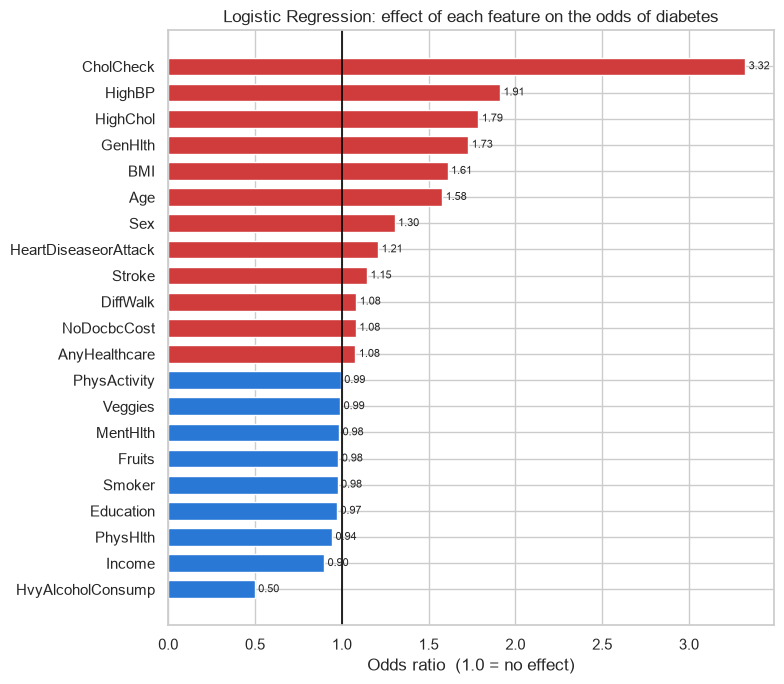

In [12]:
plot_df = odds.sort_values("Odds ratio")

plt.figure(figsize=(8, 7))
cols = ["#2a78d6" if v < 1 else "#d03b3b" for v in plot_df["Odds ratio"]]
plt.barh(plot_df["Feature"], plot_df["Odds ratio"], color=cols, height=0.68)
plt.axvline(1.0, color="black", linewidth=1.2)
plt.xlabel("Odds ratio  (1.0 = no effect)")
plt.title("Logistic Regression: effect of each feature on the odds of diabetes")
for i, v in enumerate(plot_df["Odds ratio"]):
    plt.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("logreg_odds_ratios.png", dpi=150)
plt.show()

### 7.2 LightGBM — feature importance

Importance here counts how often each feature was used to split the data across all
400 trees. It is worth comparing this ranking against the correlation analysis from
the previous notebook: features that were only moderately correlated on their own can
rank highly here, because the model uses them *in combination* with others.

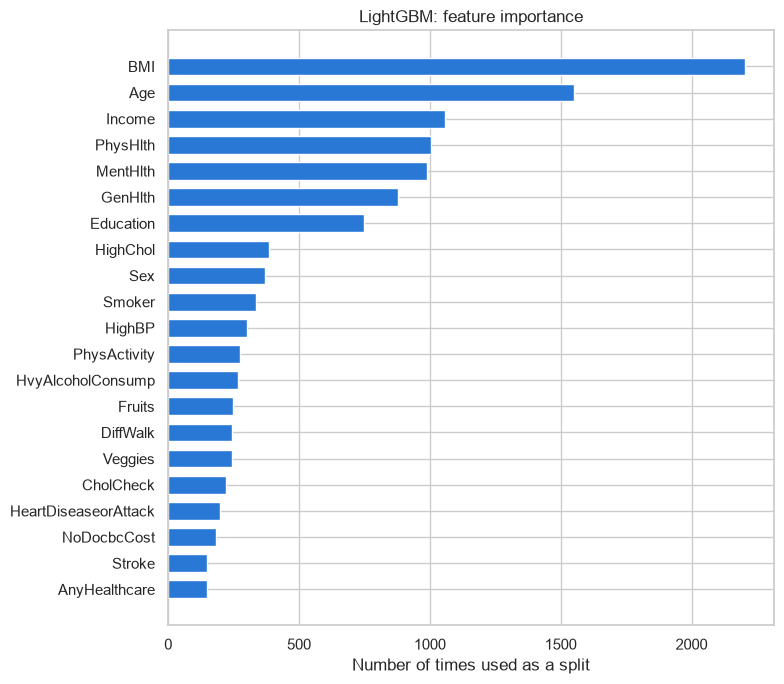

,Feature,Importance
0,BMI,2205
1,Age,1550
2,Income,1058
3,PhysHlth,1003
4,MentHlth,991
5,GenHlth,879
6,Education,747
7,HighChol,387
8,Sex,371
9,Smoker,335


In [13]:
lgbm = fitted["LightGBM"]

imp = (pd.DataFrame({
    "Feature": feature_names,
    "Importance": lgbm.feature_importances_,
}).sort_values("Importance", ascending=True).reset_index(drop=True))

plt.figure(figsize=(8, 7))
plt.barh(imp["Feature"], imp["Importance"], color="#2a78d6", height=0.68)
plt.xlabel("Number of times used as a split")
plt.title("LightGBM: feature importance")
plt.tight_layout()
plt.savefig("lightgbm_importance.png", dpi=150)
plt.show()

imp.sort_values("Importance", ascending=False).reset_index(drop=True)

### 7.3 The decision tree, drawn

Only the top three levels are shown — the full six-level tree is too wide to read.
This is the clearest single illustration of how a model actually makes its decision.

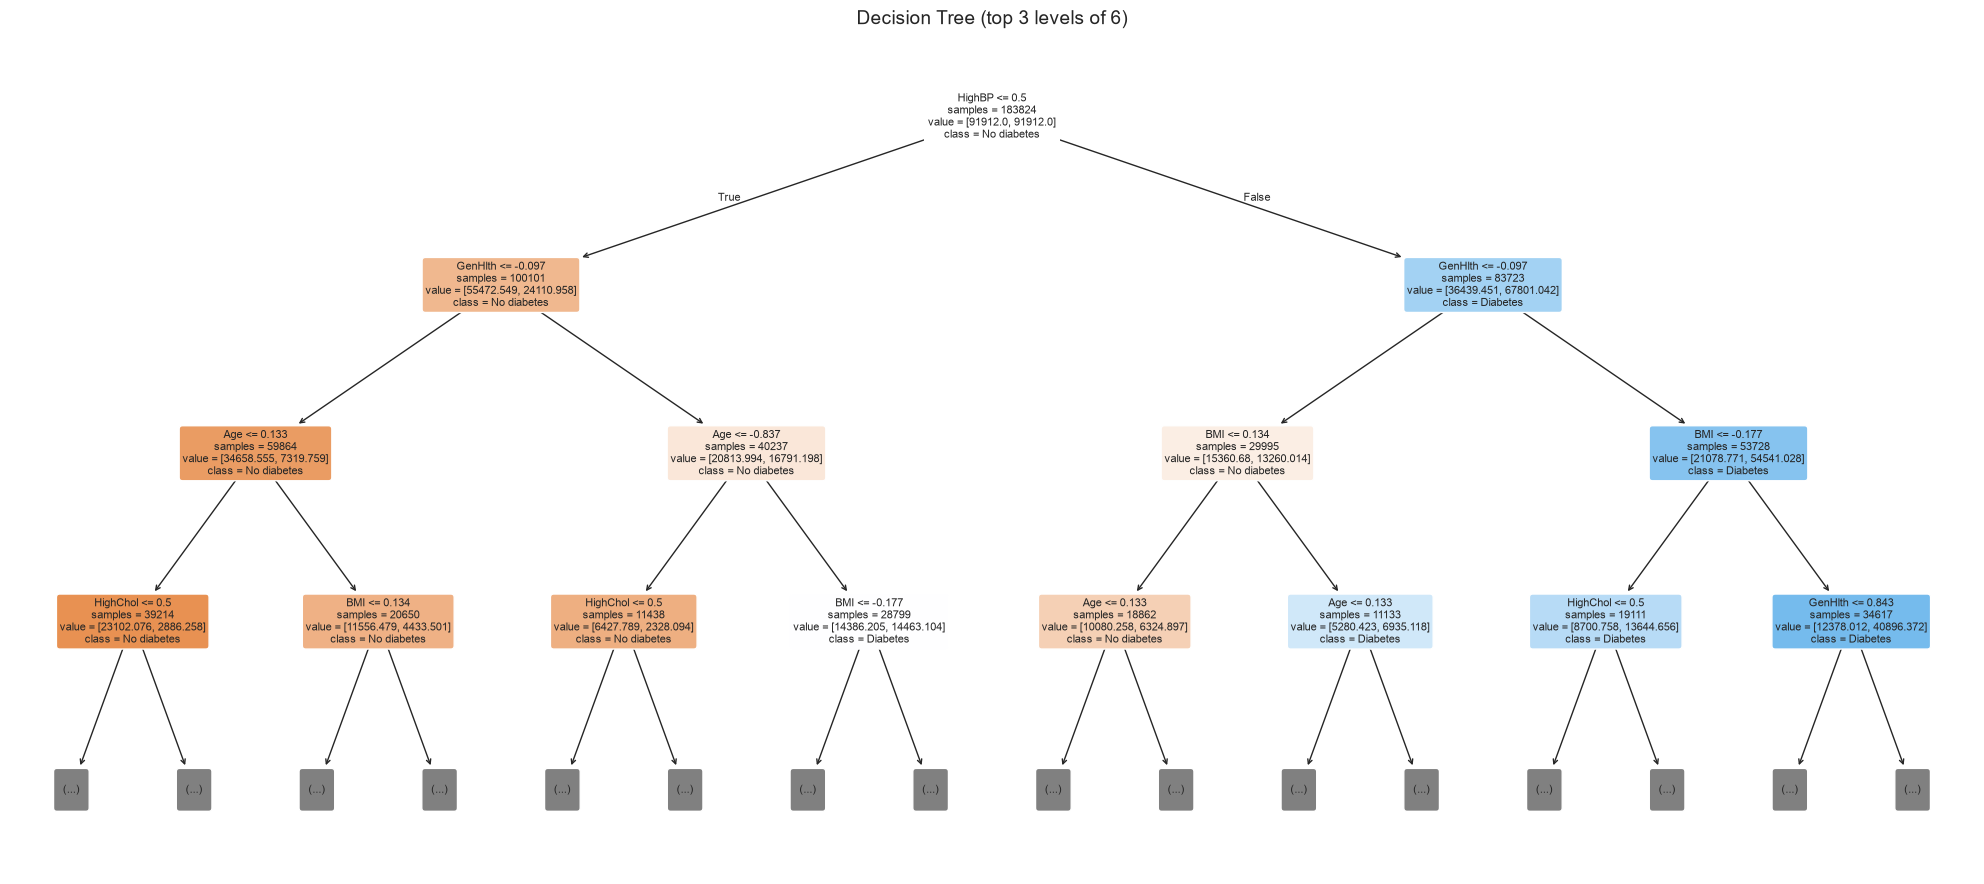

In [14]:
plt.figure(figsize=(20, 9))
plot_tree(
    fitted["Decision Tree"],
    max_depth=3,
    feature_names=feature_names,
    class_names=["No diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=8,
    impurity=False,
)
plt.title("Decision Tree (top 3 levels of 6)", fontsize=14)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 8. Where this leaves the project

Completed here — parts 6 and 7 of the required report structure:

- Four models trained, each corrected for the class imbalance.
- All four compared fairly by 5-fold stratified cross-validation on the training set.
- The winner identified, and the two most interpretable models opened up.

**Files written by this notebook**

| File | Contents |
|---|---|
| `logistic_regression.joblib` etc. | The four trained models |
| `model_comparison_results.csv` | The full score table |
| `model_comparison.png` | The five-metric comparison chart |
| `logreg_odds_ratios.png` | Odds ratios per feature |
| `lightgbm_importance.png` | LightGBM feature importance |
| `decision_tree.png` | The tree diagram |

**Still to do — parts 8 to 10:**

1. **Tune the winner.** The settings above are sensible defaults, not tuned ones. Use
   `GridSearchCV` or `RandomizedSearchCV` on the *training set only*.
2. **Tune the decision threshold.** Every model above uses the default 0.5 cut-off,
   which is rarely the right choice for imbalanced screening. Lowering it raises
   recall at the cost of precision — plot the precision-recall curve and pick a point
   that matches how many missed cases are acceptable.
3. **Evaluate on the test set — once.** Only after steps 1 and 2 are settled, and only
   for the single chosen model. Report the confusion matrix alongside the metrics, so
   the number of missed diabetic cases is visible rather than hidden inside a score.

A note on the numbers: precision sits near 0.35 for every model, meaning roughly two
in three flagged people do not have diabetes. For a screening tool whose false alarms
lead only to a cheap blood test that is an acceptable trade, but it should be stated
plainly in the report rather than left for the reader to work out.